# EDA and PCA

This notebook focuses on exploring the cleaned final dataset, producing EDA visuals, summarizing issues and assumptions made, and performing PCA on the data.

In [1]:
%pip install polars pyarrow pandas matplotlib scikit-learn jupyterlab

Note: you may need to restart the kernel to use updated packages.


In [19]:
from pathlib import Path
import math
import re
import html

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(14)

polars.config.Config

## Paths


In [3]:
PROJECT_ROOT = Path.cwd().parent

FINAL_DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "social_platform_dataset_300k.parquet"
EDA_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path:", FINAL_DATASET_PATH)
print("Exists:", FINAL_DATASET_PATH.exists())
print("EDA output dir:", EDA_OUTPUT_DIR)

Dataset path: /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/social_platform_dataset_300k.parquet
Exists: True
EDA output dir: /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/eda


## Load the final dataset

In [4]:
df = pl.read_parquet(FINAL_DATASET_PATH)
print(df.shape)
df.head()

(300000, 18)


platform,post_id,author,text,created_at,likes,retweets,…,month,year_month,score,community,num_comments,upvote_ratio,parent_id
str,str,str,str,datetime[μs],i64,i64,…,i8,str,i64,str,i64,f64,str
"""hackernews""","""16628539""","""tandav""","""One note: fresh and clean airf…",2018-03-20 09:55:04,null,null,…,3,"""2018-03""",0,null,null,null,"""16628205"""
"""reddit""","""t3_106wnce""","""EmotionalCareer8069""","""This dude is wild on the wheel…",2023-01-08 00:00:00,null,null,…,1,"""2023-01""",1,"""simracing""",0,0.6,null
"""reddit""","""t3_14bnwb4""","""ejeje21""","""ktoś grupowe rp? None""",2023-06-17 00:00:00,null,null,…,6,"""2023-06""",1,"""BestPolishInfluencer""",2,1.0,null
"""hackernews""","""9792987""","""mahouse""",""">Can you really get a beer wit…",2015-06-28 05:46:19,null,null,…,6,"""2015-06""",0,null,null,null,"""9792869"""
"""hackernews""","""26604283""","""dhbradshaw""","""Really good idea. I'd like thi…",2021-03-27 14:26:27,null,null,…,3,"""2021-03""",0,null,null,null,"""26603097"""


## Sample output for each class

Show one example row for each platform class so we can quickly see what each category looks like before deeper analysis.

In [5]:
for platform_name in sorted(df.get_column("platform").unique().to_list()):
    sample = df.filter(pl.col("platform") == platform_name).row(0, named=True)
    print(f"\n=== {platform_name.upper()} sample ===")
    print(f"author: {sample['author']}")
    print(f"created_at: {sample['created_at']}")
    print("text:")
    print(sample['text'])


=== HACKERNEWS sample ===
author: tandav
created_at: 2018-03-20 09:55:04
text:
One note: fresh and clean airflow is important, don't do this indoor with high co2 ppm (high co2 is basically poison)

=== REDDIT sample ===
author: EmotionalCareer8069
created_at: 2023-01-08 00:00:00
text:
This dude is wild on the wheel. Have you guys seen this video? None

=== TWITTER sample ===
author: BlkGirlsDoStuff
created_at: 2022-10-12 19:10:30
text:
@ShenoahAlways You know, I’m not sure…maybe Gabrielle. I always liked that name and I use it as my fake name. lol. But I don’t know!


## Basic schema and data review


In [6]:
df.schema

Schema([('platform', String),
        ('post_id', String),
        ('author', String),
        ('text', String),
        ('created_at', Datetime(time_unit='us', time_zone=None)),
        ('likes', Int64),
        ('retweets', Int64),
        ('replies', Int64),
        ('quotes', Int64),
        ('text_len', UInt32),
        ('year', Int32),
        ('month', Int8),
        ('year_month', String),
        ('score', Int64),
        ('community', String),
        ('num_comments', Int64),
        ('upvote_ratio', Float64),
        ('parent_id', String)])

Our dataset includes the standardized fields designed in our create_dataset notebook. The fields platform, post_id (A unique post_id generated by us for each post), author (The person who created the post), text (the actual text of the post itself and the most important field), and created_at (the date at which the post was created) are gauranteed to exist no matter what platform the source comes from, whereas the other fields may be platform dependent and our kept for potential additional analysis. The notebooks for each model will explicitly detail which of the shared features they will use and potentially engineer additional features as well. Currently the plan is to train the models almost exclusively based on the text field and features engineered from the actual text of the post to avoid them learning to differentiate platforms based on stuff like date posted. We are interested in the linguistic differences between posts across different platforms so looking at only the text itself, and additional features based on punctuation, text statistics, and embeddings suits our project best.

In [7]:
df.group_by("platform").len().sort("platform")

platform,len
str,u32
"""hackernews""",100000
"""reddit""",100000
"""twitter""",100000


In [8]:
df.select([
    pl.len().alias("n_rows"),
    pl.col("text").is_null().sum().alias("null_text"),
    pl.col("author").is_null().sum().alias("null_author"),
    pl.col("created_at").is_null().sum().alias("null_created_at"),
    pl.col("text_len").mean().alias("mean_text_len"),
    pl.col("text_len").median().alias("median_text_len"),
    pl.col("text_len").min().alias("min_text_len"),
    pl.col("text_len").max().alias("max_text_len"),
])

n_rows,null_text,null_author,null_created_at,mean_text_len,median_text_len,min_text_len,max_text_len
u32,u32,u32,u32,f64,f64,u32,u32
300000,0,0,0,268.85462,134.0,20,39159


We check to make sure none of the important fields (text, author, created_at) are null in our dataset, and check some basic stats about the data. The min text length was set in our create_dataset notebook to get rid of outliers and it is as expected at 20. Additionally we can see that while the median text length is at 134, the mean text length is at 268 indicating that the majority of the posts are quite short, but there are still a number of longer posts pushing the mean higher. This is around what we expected based on observing actual social media posts.

## Additional text features for EDA

These features are only for our initial analysis. The modeling notebooks will explicitly determine what features to keep and drop according to what we think will work the best.


In [9]:
def add_text_stats(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.col("text").str.count_matches(r"\?").alias("num_questions"),
        pl.col("text").str.count_matches(r"!").alias("num_exclamations"),
        pl.col("text").str.count_matches(r"#\w+").alias("num_hashtags"),
        pl.col("text").str.count_matches(r"@\w+").alias("num_mentions"),
        pl.col("text").str.count_matches(r"http[s]?://").alias("num_urls"),
        pl.col("text").str.count_matches(r"\d").alias("num_digits"),
        pl.col("text").str.count_matches(r"\b[A-Z]{2,}\b").alias("num_allcaps_words"),
        pl.col("text").str.count_matches(r"\b\w+\b").alias("num_words"),
    ]).with_columns([
        (pl.col("text_len") / pl.when(pl.col("num_words") > 0).then(pl.col("num_words")).otherwise(1)).alias("avg_word_len"),
    ])

eda_df = add_text_stats(df)
eda_df.head()

platform,post_id,author,text,created_at,likes,retweets,…,num_hashtags,num_mentions,num_urls,num_digits,num_allcaps_words,num_words,avg_word_len
str,str,str,str,datetime[μs],i64,i64,…,u32,u32,u32,u32,u32,u32,f64
"""hackernews""","""16628539""","""tandav""","""One note: fresh and clean airf…",2018-03-20 09:55:04,null,null,…,0,0,0,2,0,22,5.318182
"""reddit""","""t3_106wnce""","""EmotionalCareer8069""","""This dude is wild on the wheel…",2023-01-08 00:00:00,null,null,…,0,0,0,0,0,14,4.785714
"""reddit""","""t3_14bnwb4""","""ejeje21""","""ktoś grupowe rp? None""",2023-06-17 00:00:00,null,null,…,0,0,0,0,0,4,5.25
"""hackernews""","""9792987""","""mahouse""",""">Can you really get a beer wit…",2015-06-28 05:46:19,null,null,…,0,0,0,0,0,33,5.333333
"""hackernews""","""26604283""","""dhbradshaw""","""Really good idea. I'd like thi…",2021-03-27 14:26:27,null,null,…,0,0,0,0,0,11,4.727273


## Platform summary table

In [10]:
platform_summary = (
    eda_df.group_by("platform")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("text_len").mean().alias("mean_text_len"),
        pl.col("text_len").median().alias("median_text_len"),
        pl.col("num_words").mean().alias("mean_num_words"),
        pl.col("num_questions").mean().alias("mean_num_questions"),
        pl.col("num_exclamations").mean().alias("mean_num_exclamations"),
        pl.col("num_hashtags").mean().alias("mean_num_hashtags"),
        pl.col("num_mentions").mean().alias("mean_num_mentions"),
        pl.col("num_urls").mean().alias("mean_num_urls"),
        pl.col("avg_word_len").mean().alias("mean_avg_word_len"),
    ])
    .sort("platform")
)

platform_summary

platform,n_rows,mean_text_len,median_text_len,mean_num_words,mean_num_questions,mean_num_exclamations,mean_num_hashtags,mean_num_mentions,mean_num_urls,mean_avg_word_len
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""hackernews""",100000,375.66357,246.0,67.84555,0.38087,0.08606,0.01814,0.0076,0.3373,5.532958
"""reddit""",100000,307.22964,90.0,56.40576,0.6538,0.32144,0.0549,0.01432,0.21978,5.508974
"""twitter""",100000,123.67065,107.0,19.23004,0.09769,0.29491,0.70177,0.71975,0.66524,7.27108


We look at post statistics based on the platform the post comes from. We can see that both hacker news and reddit are on average quite a bit longer than reddit posts. Additionally punctuation across platforms seems to differ substantially, with things like hashtags and mentions being found almost exclusively in twitter, while hackernew seems to have a lot more questions than the other two. All these additional statistics seem to provide good differentiation across the sources and we will likely engineer similar features for when we actually run the models.

## Class Balance

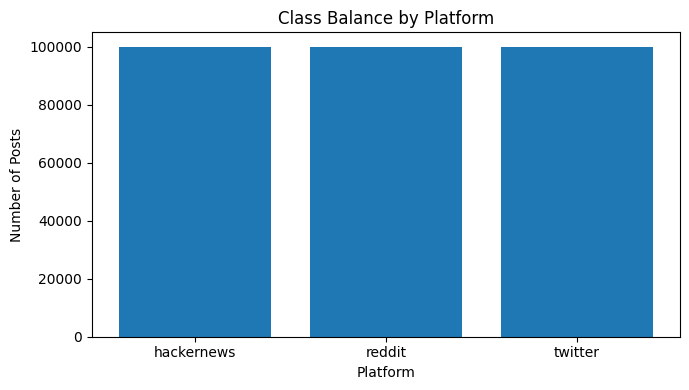

In [11]:
class_counts = eda_df.group_by("platform").len().sort("platform").to_pandas()

plt.figure(figsize=(7, 4))
plt.bar(class_counts["platform"], class_counts["len"])
plt.title("Class Balance by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "class_balance.png", dpi=150)
plt.show()

We check that the data is balanced in our dataset as we set it up to be.

## Text length distributions by platform

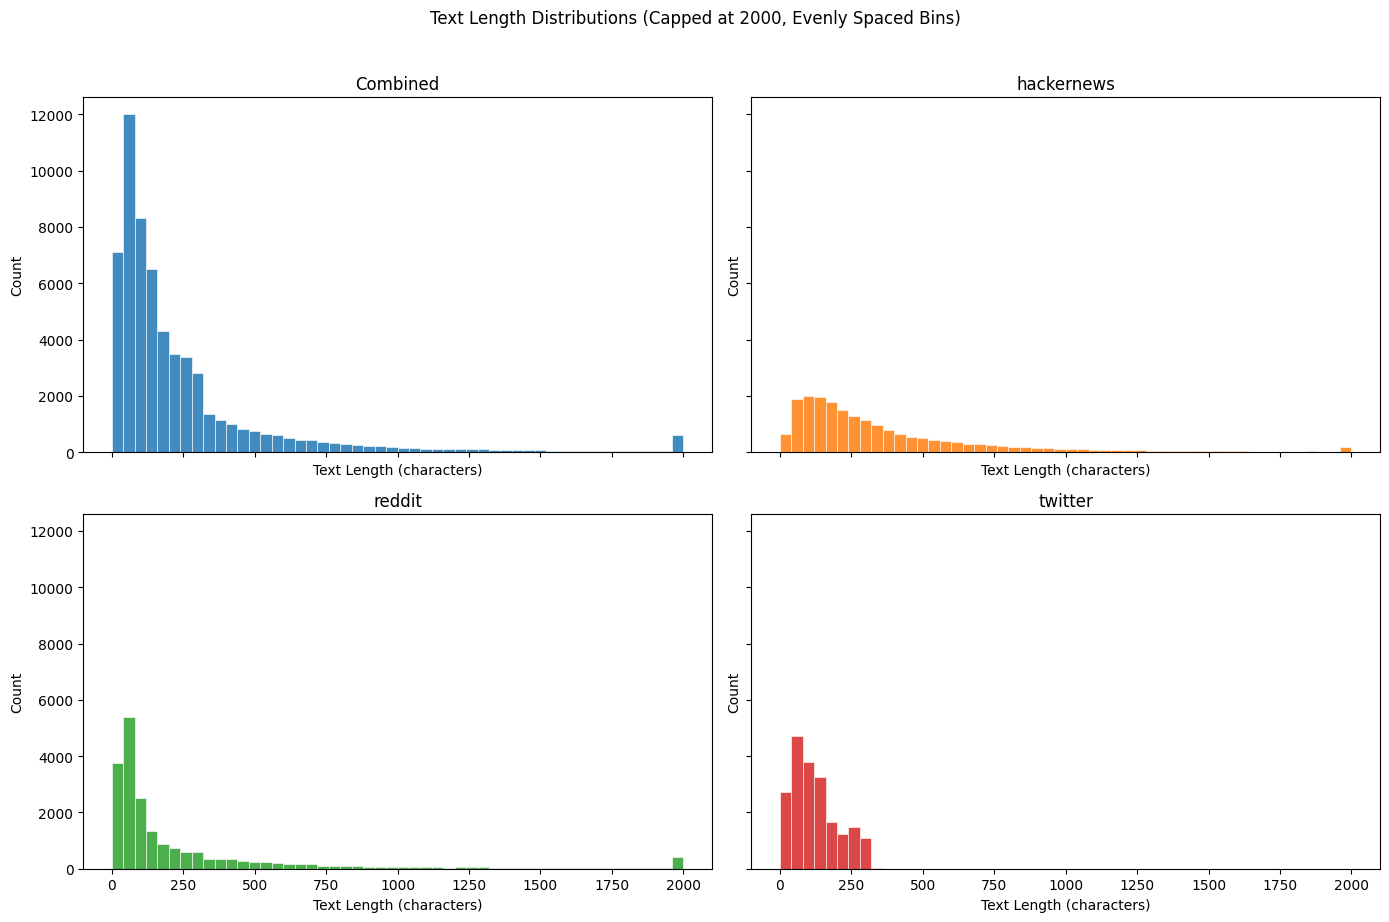

Counts over 2000 characters:
  Combined: 601
  hackernews: 186
  reddit: 415
  twitter: 0


In [12]:
sample_for_hist = (
    eda_df.select(["platform", "text_len"])
    .sample(n=min(60000, eda_df.height), shuffle=True, seed=42)
    .to_pandas()
)

platforms = sorted(sample_for_hist["platform"].unique())

max_len_cap = 2000
n_bins = 50
shared_bin_edges = np.linspace(0, max_len_cap, n_bins + 1)

groups = [
    ("Combined", sample_for_hist["text_len"]),
    ("hackernews", sample_for_hist.loc[sample_for_hist["platform"] == "hackernews", "text_len"]),
    ("reddit", sample_for_hist.loc[sample_for_hist["platform"] == "reddit", "text_len"]),
    ("twitter", sample_for_hist.loc[sample_for_hist["platform"] == "twitter", "text_len"]),
]

group_colors = {
    "Combined": "tab:blue",
    "hackernews": "tab:orange",
    "reddit": "tab:green",
    "twitter": "tab:red",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, vals) in zip(axes, groups):
    vals_capped = np.clip(vals, 0, max_len_cap)

    ax.hist(
        vals_capped,
        bins=shared_bin_edges,
        alpha=0.85,
        color=group_colors.get(name, "tab:gray"),
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title(name)
    ax.set_xlabel("Text Length (characters)")
    ax.set_ylabel("Count")

plt.suptitle("Text Length Distributions (Capped at 2000, Evenly Spaced Bins)", y=1.02)
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "text_length_hist.png", dpi=150)
plt.show()

print(f"Counts over {max_len_cap} characters:")
for name, vals in groups:
    over_cap_count = int((vals > max_len_cap).sum())
    print(f"  {name}: {over_cap_count}")

Here we compare post lengths across platforms. Any post above 2000 characters is included in the 2000 bin. We can see that most of the posts are concentrated within 100 characters, with the vast majority of posts being under 250 character. Additionally while, both hackernews and reddit have some much longer posts, twitter does not which is likely because most twitter posts are limited to 280 characters. Even though longer posts can be considered outliers we are still fine comparing them because they are still present in both reddit and hackernews which we have to differentiate between and because length of a post can greatly contribute to the linguistic style of it (short comments vs longer stories/more punctuation/etc).

## Stylistic markers by platform

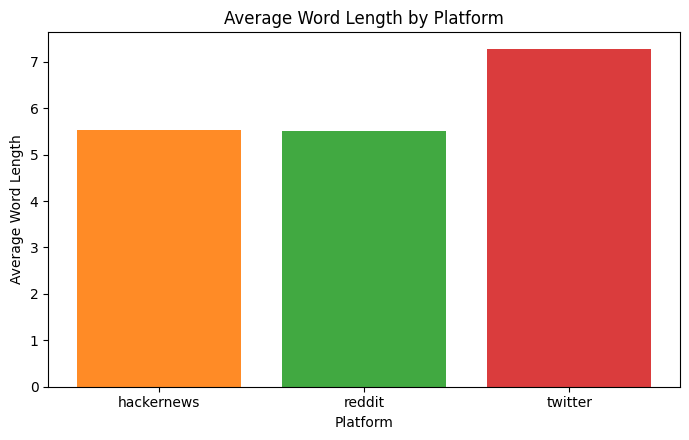

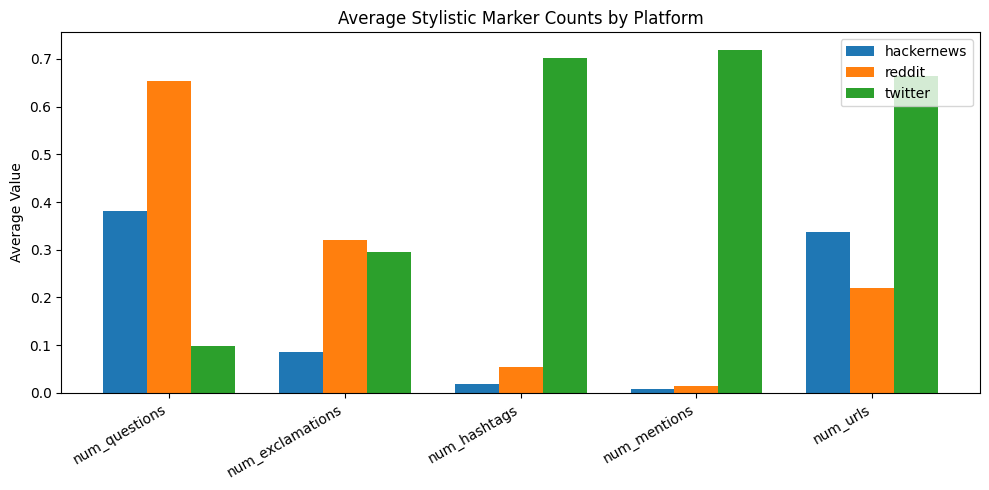

In [13]:
style_cols = [
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
    "avg_word_len",
]

style_summary = eda_df.group_by("platform").agg(
    [pl.col(c).mean().alias(c) for c in style_cols]
).sort("platform").to_pandas()

# Chart 1: average word length only
plt.figure(figsize=(7, 4.5))
plt.bar(
    style_summary["platform"],
    style_summary["avg_word_len"],
    color=["tab:orange", "tab:green", "tab:red"],
    alpha=0.9,
)
plt.title("Average Word Length by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Word Length")
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "style_avg_word_len_bar.png", dpi=150)
plt.show()

# Chart 2: remaining stylistic marker fields
other_style_cols = [
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
]

x = np.arange(len(other_style_cols))
width = 0.25

plt.figure(figsize=(10, 5))
for i, platform in enumerate(style_summary["platform"]):
    plt.bar(x + i * width, style_summary.loc[i, other_style_cols], width=width, label=platform)

plt.xticks(x + width, other_style_cols, rotation=30, ha="right")
plt.title("Average Stylistic Marker Counts by Platform")
plt.ylabel("Average Value")
plt.legend()
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "style_stats_bar.png", dpi=150)
plt.show()

We now expand on the text statistics from each platform found above. For average wor length, hackernews and reddit are the same which is expected, but twitter is longer. This is a bit surprising but could be a result of a higher number of long urls or usernames or similar linguistic artifacts. This is reinforced by the second chart where twitter has a much higher use of hashtags, mentions (@) and urls than the other sources. Additionally reddit seems to have the most questions, while hackernews has the least amount of explamations. These all appear to be relevant statistics that could be expanded into actual features for the models to train on because they capture linguistic and tonal differances between the platforms based on the text and punctations of the post which is what we want the models to be focusing on.

Year-month activity

Note this is for analysis, but we will not use year-month data when modeling because it is unrelated to the text features we are interested in and the model could learn to classify based on the year-month data based on biases in our dataset.


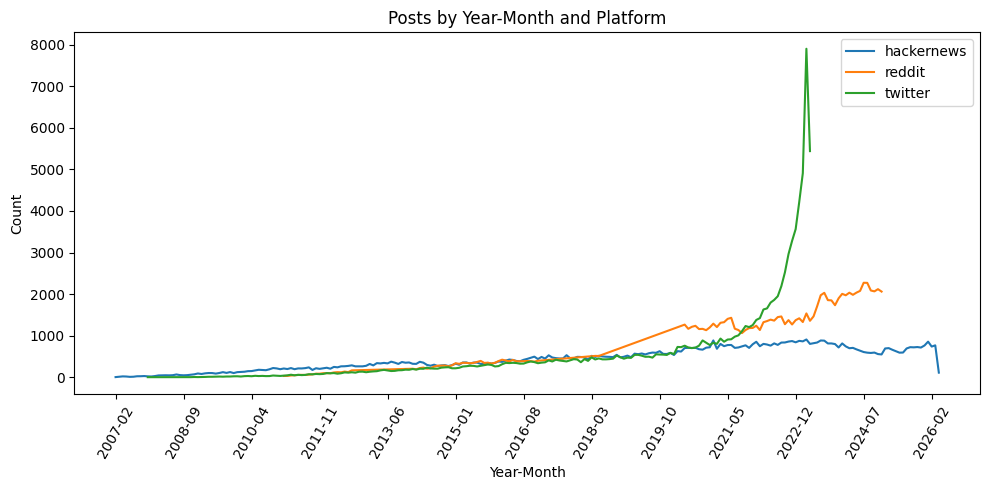

In [14]:
if "year_month" in eda_df.columns:
    ym_counts = (
        eda_df.group_by(["platform", "year_month"])
        .len()
        .sort(["platform", "year_month"])
        .to_pandas()
    )

    plt.figure(figsize=(10, 5))
    for platform in sorted(ym_counts["platform"].unique()):
        sub = ym_counts[ym_counts["platform"] == platform]
        plt.plot(sub["year_month"], sub["len"], label=platform)

    # Keep labels readable
    all_months = sorted(ym_counts["year_month"].unique())
    tick_step = max(1, len(all_months) // 12)
    sparse_months = all_months[::tick_step]

    plt.title("Posts by Year-Month and Platform")
    plt.xlabel("Year-Month")
    plt.ylabel("Count")
    plt.xticks(sparse_months, rotation=60)
    plt.legend()
    plt.tight_layout()
    plt.savefig(EDA_OUTPUT_DIR / "year_month_counts.png", dpi=150)
    plt.show()
else:
    print("year_month column not found")

In [15]:
# Earliest/latest entry table by platform
if "created_at" in eda_df.columns and "year_month" in eda_df.columns:
    date_range_summary = (
        eda_df.group_by("platform")
        .agg(
            [
                pl.col("created_at").min().alias("earliest_created_at"),
                pl.col("created_at").max().alias("latest_created_at"),
                pl.col("year_month").min().alias("earliest_year_month"),
                pl.col("year_month").max().alias("latest_year_month"),
            ]
        )
        .sort("platform")
    )

    print("Earliest and latest entries by platform:")
    display(date_range_summary)
else:
    print("created_at or year_month column not found")

Earliest and latest entries by platform:


platform,earliest_created_at,latest_created_at,earliest_year_month,latest_year_month
str,datetime[μs],datetime[μs],str,str
"""hackernews""",2007-02-20 02:56:06,2026-04-06 20:23:01,"""2007-02""","""2026-04"""
"""reddit""",2011-01-01 00:00:00,2024-12-31 00:00:00,"""2011-01""","""2024-12"""
"""twitter""",2007-11-12 02:49:14,2023-04-20 05:00:01,"""2007-11""","""2023-04"""


Now we look at the dates of the posts based on source. We can see that all the sources come from between 2007 and 2026 and each cover most of that time period. This is important so that the model doesn't accidently learn specific details relevant to time encoded within the text of the posts (like events being referenced) rather than actual posting style. Additionally the models themselves won't be trained using time data to further prevent this. In general we can see that we have less data from early on and then as we approach the 2020s we get an increased amount of data.

In [16]:
## Export EDA table artifacts for dashboard
if "date_range_summary" in globals():
    date_range_export = date_range_summary.to_pandas() if hasattr(date_range_summary, "to_pandas") else date_range_summary.copy()
    export_path = EDA_OUTPUT_DIR / "date_range_summary.csv"
    date_range_export.to_csv(export_path, index=False)
    print(f"Saved date range table to: {export_path}")
else:
    print("date_range_summary is not defined yet. Run the date-range summary cell first.")

Saved date range table to: /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/eda/date_range_summary.csv


## PCA and clustering on engineered text statistics

We intentionally exclude features like created_at, year, month, year-month, IDs, authors, and metadata because those may encode platform/source artifacts instead of language style.


In [17]:
feature_cols = [
    "text_len",
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
    "num_digits",
    "num_allcaps_words",
    "num_words",
    "avg_word_len",
]

stats_pdf = eda_df.select(["platform"] + feature_cols).to_pandas()
X_stats = stats_pdf[feature_cols].copy()
y_platform = stats_pdf["platform"].copy()

scaler = StandardScaler()
X_stats_scaled = scaler.fit_transform(X_stats)

pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_stats_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "platform": y_platform,
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
pca_df.head()

Explained variance ratio: [0.32361807 0.13333784]


,PC1,PC2,platform
0,-0.527330,-0.436377,hackernews
1,-0.398583,-0.739212,reddit
2,-0.500085,-0.588636,reddit
3,-0.219739,-0.623927,hackernews
4,-0.656747,-0.593044,hackernews


PCA of engineered text statistics

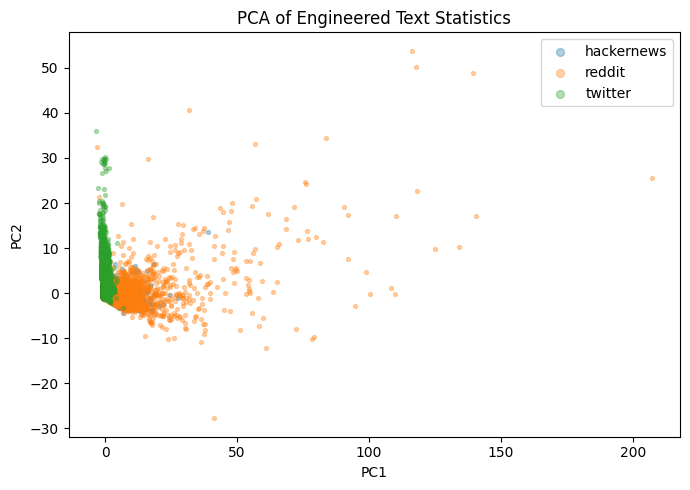

In [18]:
plt.figure(figsize=(7, 5))
for platform in sorted(pca_df["platform"].unique()):
    sub = pca_df[pca_df["platform"] == platform]
    plt.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.35, label=platform)

plt.title("PCA of Engineered Text Statistics")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "pca_stats_scatter.png", dpi=150)
plt.show()